In [23]:
import geemap
import ee
import geopandas as gpd

In [24]:
ee.Authenticate()

True

In [25]:
ee.Initialize(project='bangalore-green-cover-analysis')

In [26]:
m = geemap.Map()
m

Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', transp…

In [27]:
m.add_basemap('OpenStreetMap')

In [28]:
wards = gpd.read_file(r"C:\Users\adhva\Desktop\M3DM\Bangalore heat project\Bangalore Final Wards Map.kml")
print(f"Number of wards: {len(wards)}")

Number of wards: 369


In [29]:
m.add_gdf(wards, layer_name="Bangalore Wards")
summer_filters = ee.Filter.Or([
    ee.Filter.date('2020-03-01', '2020-06-30'),
    ee.Filter.date('2021-03-01', '2021-06-30'),
    ee.Filter.date('2022-03-01', '2022-06-30'),
    ee.Filter.date('2023-03-01', '2023-06-30'),
    ee.Filter.date('2024-03-01', '2024-06-30'),
    ee.Filter.date('2025-03-01', '2025-06-30'),
])

In [30]:
aoi = geemap.geopandas_to_ee(wards).geometry()

def mask_s2_clouds(image):
    """Masks clouds in a Sentinel-2 image using the QA60 band."""
    qa = image.select('QA60')
    
    cloud_bit_mask = 1 << 10
    cirrus_bit_mask = 1 << 11
    
    mask = (
        qa.bitwiseAnd(cloud_bit_mask).eq(0)
        .And(qa.bitwiseAnd(cirrus_bit_mask).eq(0))
    )
    
    return image.updateMask(mask).divide(10000)

sentinel_collection = (
    ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterBounds(aoi)
    .filter(summer_filters)
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
    .map(mask_s2_clouds)
)

sentinel_image = sentinel_collection.median().clip(aoi)

vis_params = {
    'bands': ['B4', 'B3', 'B2'], 
    'min': 0.0,
    'max': 0.3,
}

m.add_layer(sentinel_image, vis_params, 'Sentinel-2 RGB - Bangalore')

In [31]:
ndvi = sentinel_image.normalizedDifference(['B8', 'B4']).rename('NDVI')

ndvi_vis = {
    'min': -0.5,
    'max': 0.8,
    'palette': ['grey', 'red','brown','orange', 'yellow','lightgreen', 'green', 'blue']
}

m.add_layer(ndvi, ndvi_vis, 'NDVI - Tree Coverage')

legend_dict = {
    'Water / Shadow (-0.5)':    '#808080',  
    'Built-up / Urban (-0.3)':  '#FF0000',  
    'Bare Soil (-0.1)':         '#A52A2A',  
    'Dry Vegetation (0.1)':     '#FFA500',  
    'Sparse Vegetation (0.3)':  '#FFFF00',  
    'Light Vegetation (0.4)':   '#90EE90',  
    'Moderate Canopy (0.6)':    '#008000',  
    'Dense Canopy (0.8)':       '#0000FF',  
}

m.add_legend(
    title='NDVI - Tree Coverage',
    legend_dict=legend_dict,
    position='bottomright'
)

In [32]:
def mask_landsat_clouds(image):
    """Masks clouds in Landsat 8 using QA_PIXEL band."""
    qa = image.select('QA_PIXEL')
    cloud_bit_mask = 1 << 3
    shadow_bit_mask = 1 << 4
    mask = (
        qa.bitwiseAnd(cloud_bit_mask).eq(0)
        .And(qa.bitwiseAnd(shadow_bit_mask).eq(0))
    )
    return image.updateMask(mask)

def apply_scale_factors(image):
    """Converts ST_B10 to LST in Celsius using official C2 scale/offset."""
    thermal = image.select('ST_B10').multiply(0.00341802).add(149.0) 
    lst_celsius = thermal.subtract(273.15).rename('LST')
    return image.addBands(lst_celsius)

lst_collection = (
    ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')
    .filterBounds(aoi)
    .filter(summer_filters)
    .filter(ee.Filter.lt('CLOUD_COVER', 20))
    .map(mask_landsat_clouds)
    .map(apply_scale_factors)
)

lst_image = lst_collection.median().select('LST').clip(aoi)

lst_vis_params = {
    'min': 25,
    'max': 40,  # Celsius range, sensible for Bangalore dry season
    'palette': ['white', 'blue', 'green', 'yellow', '#FF9133', 'red']
}

m.add_layer(lst_image, lst_vis_params, 'LST - Bangalore')

In [33]:
m

Map(center=[np.float64(12.9880550526928), np.float64(77.62197179945835)], controls=(WidgetControl(options=['po…

In [34]:
def calculate_ndbi(image):
    """
    Calculate NDBI (Normalized Difference Built-up Index)
    NDBI = (SWIR - NIR) / (SWIR + NIR)
    For Landsat 8 Collection 2:
    - NIR = SR_B5 (Band 5 - 0.85-0.88 μm)
    - SWIR = SR_B6 (Band 6 - 1.57-1.65 μm)
    """
    swir = image.select('SR_B6')
    nir = image.select('SR_B5') 
    
    ndbi = swir.subtract(nir).divide(swir.add(nir)).rename('NDBI')
    return image.addBands(ndbi)

ndbi_collection = (
    ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')
    .filterBounds(aoi)
    .filter(summer_filters)
    .filter(ee.Filter.lt('CLOUD_COVER', 20))
    .map(mask_landsat_clouds)
    .map(calculate_ndbi) 
)

ndbi_image = ndbi_collection.select('NDBI').median().clip(aoi)

ndbi_vis_params = {
    'min': -0.3,
    'max': 0.5,
    'palette': ['#2E8B57',
                '#FFFF00', 
                '#FF8C00', 
                '#FF0000', 
                '#8B0000'] 
}

m.add_layer(ndbi_image, ndbi_vis_params, 'NDBI - Built-up Index')

ndbi_legend = {
    'Vegetation (< -0.1)': '#2E8B57',
    'Bare Soil (-0.1 to 0.1)': '#FFFF00',
    'Low Built-up (0.1 to 0.3)': '#FF8C00',
    'Moderate Built-up (0.3 to 0.5)': '#FF0000',
    'Dense Built-up (> 0.5)': '#8B0000'
}

m.add_legend(title='NDBI - Built-up Density', legend_dict=ndbi_legend, position='bottomright')

In [35]:
urban_index = ndbi_image.subtract(ndvi).rename('Urban_Index')

urban_vis = {
    'min': -0.5,
    'max': 0.5,
    'palette': ['green', 'yellow', 'orange', 'red', 'darkred']
}

m.add_layer(urban_index, urban_vis, 'Urban Index (NDBI - NDVI)')

In [36]:
import pandas as pd
import numpy as np

def extract_ward_features(wards_gdf, image, band_name, scale=30):
    """Extract mean value of an image for each ward polygon"""
    def get_mean(feature):
        geom = ee.Geometry.Polygon(feature.geometry.__geo_interface__['coordinates'])
        mean_val = image.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=geom,
            scale=scale,
            bestEffort=True
        ).get(band_name)
        return mean_val.getInfo()
    
    wards_gdf[f'{band_name}_mean'] = wards_gdf.apply(lambda row: get_mean(row), axis=1)
    return wards_gdf

wards_with_features = wards.copy()

print("Extracting NDVI...")
ndvi_by_ward = ndvi.reduceRegions(
    collection=geemap.geopandas_to_ee(wards),
    reducer=ee.Reducer.mean(),
    scale=30
)
ndvi_values = ndvi_by_ward.aggregate_array('mean').getInfo()
wards_with_features['NDVI_mean'] = ndvi_values

print("Extracting LST...")
lst_by_ward = lst_image.reduceRegions(
    collection=geemap.geopandas_to_ee(wards),
    reducer=ee.Reducer.mean(),
    scale=30
)
lst_values = lst_by_ward.aggregate_array('mean').getInfo()
wards_with_features['LST_mean'] = lst_values

print("Extracting NDBI...")
ndbi_by_ward = ndbi_image.reduceRegions(
    collection=geemap.geopandas_to_ee(wards),
    reducer=ee.Reducer.mean(),
    scale=30
)
ndbi_values = ndbi_by_ward.aggregate_array('mean').getInfo()
wards_with_features['NDBI_mean'] = ndbi_values

print("Extracting Urban Index...")
urban_by_ward = urban_index.reduceRegions(
    collection=geemap.geopandas_to_ee(wards),
    reducer=ee.Reducer.mean(),
    scale=30
)
urban_values = urban_by_ward.aggregate_array('mean').getInfo()
wards_with_features['UrbanIndex_mean'] = urban_values

print("Done! Data extracted for all wards.")

Extracting NDVI...
Extracting LST...
Extracting NDBI...
Extracting Urban Index...
Done! Data extracted for all wards.


In [37]:
def normalize(series):
    return (series - series.min()) / (series.max() - series.min()) * 100

wards_with_features['NDVI_norm'] = normalize(wards_with_features['NDVI_mean'])
wards_with_features['LST_norm'] = normalize(wards_with_features['LST_mean'])
wards_with_features['NDBI_norm'] = normalize(wards_with_features['NDBI_mean'])

wards_with_features['Priority_Score'] = (
    (100 - wards_with_features['NDVI_norm']) * 0.5 +  
    wards_with_features['LST_norm'] * 0.3 +           
    wards_with_features['NDBI_norm'] * 0.2           
)

wards_with_features['Priority_Tier'] = pd.cut(
    wards_with_features['Priority_Score'],
    bins=[0, 33, 66, 100],
    labels=['Low Priority', 'Medium Priority', 'High Priority']
)

top_10 = wards_with_features.nlargest(10, 'Priority_Score')[['NDVI_mean', 'LST_mean', 'NDBI_mean', 'Priority_Score']]
print("Top 10 Priority Wards for Tree Planting:")
print(top_10)

Top 10 Priority Wards for Tree Planting:
     NDVI_mean   LST_mean  NDBI_mean  Priority_Score
82    0.107606  40.964507   0.039195       94.371701
69    0.120798  41.295481   0.039553       94.174490
316   0.111388  40.751147   0.040498       93.151219
351   0.112433  41.021020   0.030337       92.365586
301   0.104394  40.000804   0.037339       90.132832
141   0.125535  40.635165   0.034427       89.645638
308   0.109315  39.991929   0.029785       88.059163
344   0.128823  40.507150   0.029802       87.789458
296   0.092300  39.159342   0.034741       87.483832
46    0.121457  40.253440   0.028341       87.359674


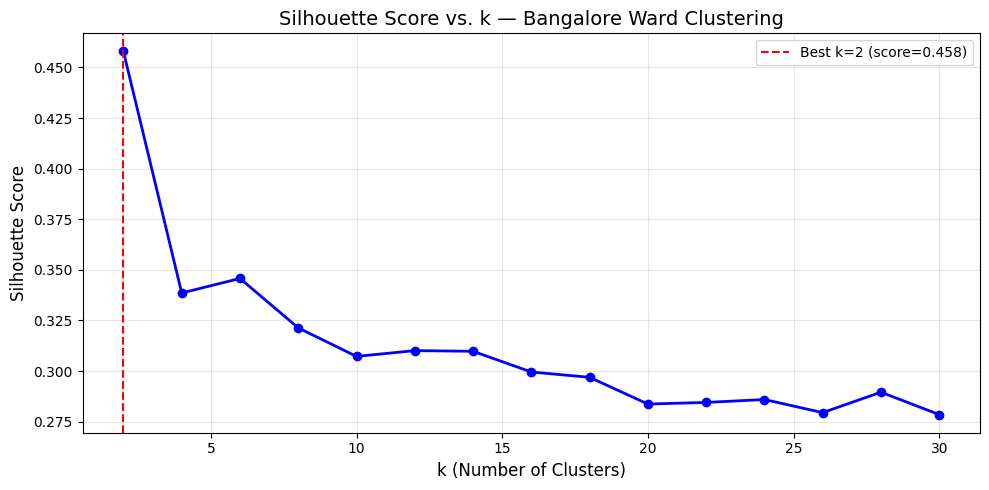

Best k: 2  |  Silhouette Score: 0.4579


In [38]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

features = ['NDVI_mean', 'LST_mean', 'NDBI_mean']
X_opt = wards_with_features[features].dropna()

scaler_opt = StandardScaler()
X_scaled_opt = scaler_opt.fit_transform(X_opt)

k_values = range(2, 31, 2) 
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled_opt)
    silhouette_scores.append(silhouette_score(X_scaled_opt, labels))

best_k = k_values[np.argmax(silhouette_scores)]
best_score = max(silhouette_scores)

plt.figure(figsize=(10, 5))
plt.plot(k_values, silhouette_scores, marker='o', linewidth=2, color='blue')
plt.axvline(x=best_k, color='red', linestyle='--',
            label=f'Best k={best_k} (score={best_score:.3f})')
plt.xlabel('k (Number of Clusters)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.title('Silhouette Score vs. k — Bangalore Ward Clustering', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Best k: {best_k}  |  Silhouette Score: {best_score:.4f}')

In [39]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

features = ['NDVI_mean', 'LST_mean', 'NDBI_mean']
X = wards_with_features[features].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
wards_with_features.loc[X.index, 'Cluster'] = kmeans.fit_predict(X_scaled)

cluster_summary = wards_with_features.groupby('Cluster')[features].mean()
print("Cluster Characteristics:")
print(cluster_summary)

def label_cluster(row):
    if row['NDVI_mean'] < 0.2 and row['LST_mean'] > 35:
        return 'High Priority - Needs Trees'
    elif row['NDVI_mean'] < 0.3 and row['LST_mean'] > 32:
        return 'Medium Priority'
    else:
        return 'Low Priority - Already Green'

wards_with_features['Cluster_Label'] = wards_with_features.apply(label_cluster, axis=1)

Cluster Characteristics:
         NDVI_mean   LST_mean  NDBI_mean
Cluster                                 
0.0       0.254264  38.444797  -0.007642
1.0       0.186867  39.659765   0.014267
2.0       0.358082  37.312018  -0.034625


In [40]:
cluster_styles = {
    'High Priority - Needs Trees': {"color": "#000000", "fillColor": "#FF0000", "fillOpacity": 0.5, "weight": 1},
    'Medium Priority':             {"color": "#000000", "fillColor": "#FFA500", "fillOpacity": 0.5, "weight": 1},
    'Low Priority - Already Green':{"color": "#000000", "fillColor": "#00FF00", "fillOpacity": 0.5, "weight": 1},
}

for label, style in cluster_styles.items():
    subset = wards_with_features[wards_with_features['Cluster_Label'] == label]
    if not subset.empty:
        m.add_gdf(subset, layer_name=label, style=style)

m

Map(center=[np.float64(12.9880550526928), np.float64(77.62197179945835)], controls=(WidgetControl(options=['po…

In [41]:
high_priority_count = len(wards_with_features[wards_with_features['Cluster_Label'] == 'High Priority - Needs Trees'])
medium_priority_count = len(wards_with_features[wards_with_features['Cluster_Label'] == 'Medium Priority'])

print("=" * 60)
print("BANGALORE TREE PLANTING RECOMMENDATIONS")
print("=" * 60)
print()
print(f"Total Wards Analyzed: {len(wards_with_features)}")
print(f"High Priority Wards: {high_priority_count}")
print(f"Medium Priority Wards: {medium_priority_count}")
print()
print("KEY FINDINGS:")
print(f"- Average NDVI (tree cover) in high-priority areas: {wards_with_features[wards_with_features['Cluster_Label'] == 'High Priority - Needs Trees']['NDVI_mean'].mean():.2f}")
print(f"- Average LST in high-priority areas: {wards_with_features[wards_with_features['Cluster_Label'] == 'High Priority - Needs Trees']['LST_mean'].mean():.1f}°C")
print(f"- Temperature difference between high and low priority: {wards_with_features[wards_with_features['Cluster_Label'] == 'High Priority - Needs Trees']['LST_mean'].mean() - wards_with_features[wards_with_features['Cluster_Label'] == 'Low Priority - Already Green']['LST_mean'].mean():.1f}°C")
print()
print("RECOMMENDATIONS:")
print("1. IMMEDIATE ACTION (High Priority Wards):")
print("   - Plant native, fast-growing canopy trees in these 10 wards")
print("   - Prioritize road medians, empty lots, and park edges")
print("   - Expected temperature reduction: 2-4°C within 5 years")
print()
print("2. MEDIUM-TERM (Medium Priority Wards):")
print("   - Protect existing trees from removal")
print("   - Add street trees and small parks")
print()
print("3. PRESERVATION (Low Priority Wards):")
print("   - Maintain existing green cover")
print("   - No new large-scale planting needed")

BANGALORE TREE PLANTING RECOMMENDATIONS

Total Wards Analyzed: 369
High Priority Wards: 124
Medium Priority Wards: 166

KEY FINDINGS:
- Average NDVI (tree cover) in high-priority areas: 0.16
- Average LST in high-priority areas: 39.4°C
- Temperature difference between high and low priority: 1.7°C

RECOMMENDATIONS:
1. IMMEDIATE ACTION (High Priority Wards):
   - Plant native, fast-growing canopy trees in these 10 wards
   - Prioritize road medians, empty lots, and park edges
   - Expected temperature reduction: 2-4°C within 5 years

2. MEDIUM-TERM (Medium Priority Wards):
   - Protect existing trees from removal
   - Add street trees and small parks

3. PRESERVATION (Low Priority Wards):
   - Maintain existing green cover
   - No new large-scale planting needed


In [42]:
wards_with_features.to_csv('bangalore_tree_priority_wards.csv', index=False)
wards_with_features.to_file('bangalore_priority_zones.geojson', driver='GeoJSON')